<a href="https://colab.research.google.com/github/AdilM01/AI-Projects/blob/feature%2Fai-projects/weather_prediction_using_lstm_ipyn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import RepeatVector
from tensorflow.keras.layers import TimeDistributed
from tensorflow.keras.layers import Dense

import matplotlib.pyplot as plt

In [ ]:
df= pd.read_csv("/content/DailyDelhiClimateTrain.csv")
df

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000
...,...,...,...,...,...
1457,2016-12-28,17.217391,68.043478,3.547826,1015.565217
1458,2016-12-29,15.238095,87.857143,6.000000,1016.904762
1459,2016-12-30,14.095238,89.666667,6.266667,1017.904762
1460,2016-12-31,15.052632,87.000000,7.325000,1016.100000


In [ ]:
import pandas as pd

df = pd.read_csv("/content/DailyDelhiClimateTrain.csv")

print(df.columns)

Index(['date', 'meantemp', 'humidity', 'wind_speed', 'meanpressure'], dtype='object')


Feature selection

In [ ]:
features = [
    'meantemp',
    'humidity',
    'wind_speed',
    'meanpressure'
]

data = df[features]

Handling Missing values

In [ ]:
data = data.replace(" ", np.nan)

data = data.apply(pd.to_numeric, errors="coerce")

data = data.fillna(method="ffill")

data = data.fillna(method="bfill")

/tmp/ipykernel_1057/570617875.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data = data.fillna(method="ffill")
/tmp/ipykernel_1057/570617875.py:7: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data = data.fillna(method="bfill")


Normalize

In [ ]:
scaler = MinMaxScaler()

scaled = scaler.fit_transform(data)

Create Sequences

In [ ]:
TIME_STEPS = 14

X = []

for i in range(len(scaled)-TIME_STEPS):

    X.append(scaled[i:i+TIME_STEPS])

X = np.array(X)

print(X.shape)

(1448, 14, 4)


Encoder-Decoder

In [ ]:
timesteps = X.shape[1]
features = X.shape[2]

inputs = Input(shape=(timesteps,features))

# Encoder
encoded = LSTM(64,activation='relu')(inputs)

# Bottleneck
decoded = RepeatVector(timesteps)(encoded)

# Decoder
decoded = LSTM(64,
               activation='relu',
               return_sequences=True)(decoded)

outputs = TimeDistributed(Dense(features))(decoded)

model = Model(inputs,outputs)

model.compile(
    optimizer='adam',
    loss='mse'
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 14, 4)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_1 (RepeatVector)  │ (None, 14, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 14, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 14, 4)          │           260 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,948 (199.02 KB)

 Trainable params: 50,948 (199.02 KB)

 Non-trainable params: 0 (0.00 B)

Train

In [ ]:
history = model.fit(

    X,
    X,

    epochs=50,

    batch_size=32,

    validation_split=0.2,

    shuffle=True

)

Epoch 1/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 10s 143ms/step - loss: 0.0686 - val_loss: 0.0302
Epoch 2/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0174 - val_loss: 0.0121
Epoch 3/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0093 - val_loss: 0.0072
Epoch 4/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0068 - val_loss: 0.0063
Epoch 5/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0063 - val_loss: 0.0059
Epoch 6/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0059 - val_loss: 0.0060
Epoch 7/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0056 - val_loss: 0.0055
Epoch 8/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0055 - val_loss: 0.0054
Epoch 9/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0053 - val_loss: 0.0054
Epoch 10/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0051 - val_loss: 0.0054
Epoch 11/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0051 - val_loss: 0.0054
Epoch 12/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0049 - val

Reconstruction

In [ ]:
pred = model.predict(X)

46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step


Reconstruction Error

In [ ]:
mse = np.mean(np.square(X-pred),axis=(1,2))

Threshold

In [ ]:
threshold = np.percentile(mse,95)

print("Threshold =",threshold)

Threshold = 0.008718286247243672


Detect Anomalies

In [ ]:
anomaly = mse > threshold

print("Total anomalies =",anomaly.sum())

Total anomalies = 73


Find Dates of Anomalies

In [ ]:
dates = df["date"][TIME_STEPS:]

anomaly_dates = dates[anomaly]

print(anomaly_dates)

252     2013-09-10
253     2013-09-11
254     2013-09-12
255     2013-09-13
256     2013-09-14
           ...    
1194    2016-04-09
1195    2016-04-10
1196    2016-04-11
1251    2016-06-05
1256    2016-06-10
Name: date, Length: 73, dtype: object


Plots

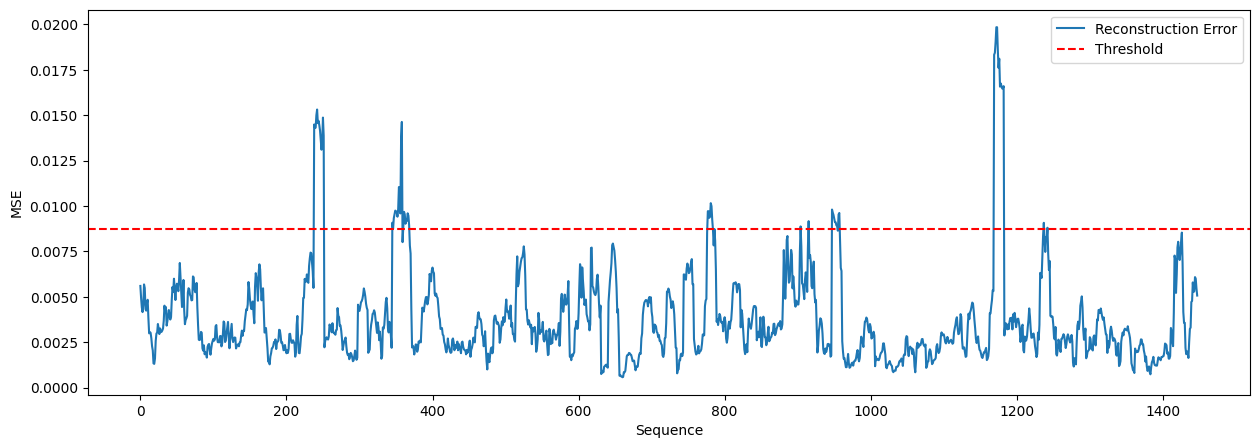

In [ ]:
plt.figure(figsize=(15,5))

plt.plot(mse,label="Reconstruction Error")

plt.axhline(
    threshold,
    color='red',
    linestyle='--',
    label='Threshold'
)

plt.legend()

plt.xlabel("Sequence")

plt.ylabel("MSE")

plt.show()

Mark Anomalies on Temperature

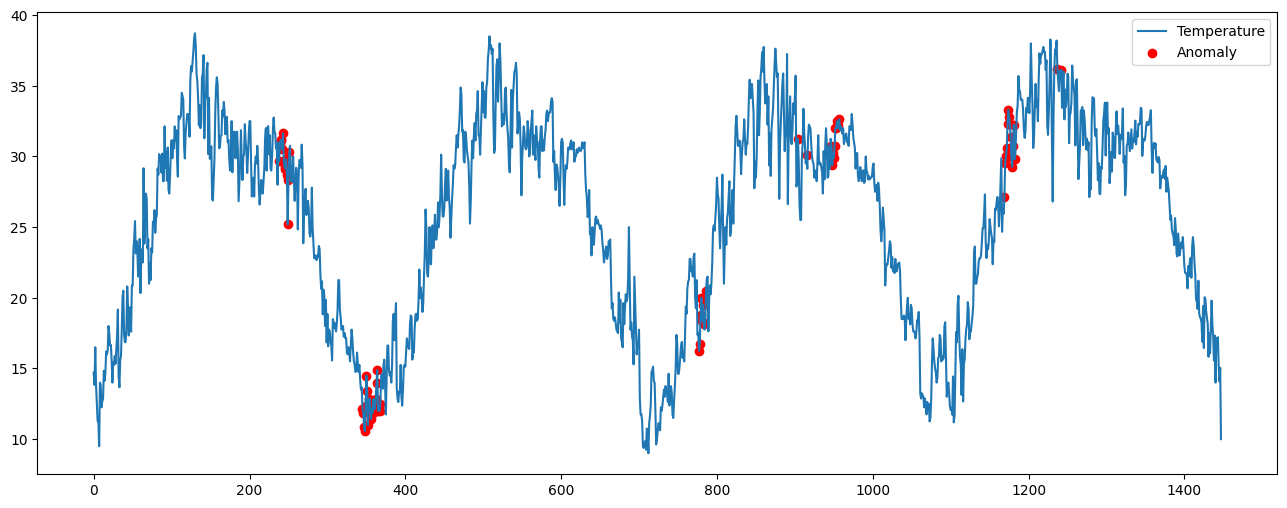

In [ ]:
temperature = df["meantemp"][TIME_STEPS:]

plt.figure(figsize=(16,6))

plt.plot(temperature.values,label="Temperature")

plt.scatter(
    np.where(anomaly)[0],
    temperature[anomaly],
    color="red",
    label="Anomaly"
)

plt.legend()

plt.show()

Save model

In [ ]:
model.save("weather_anomaly_detector1.keras")

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import joblib
import pandas as pd

train_df = pd.read_csv("DailyDelhiClimateTrain.csv")

features = [
    "meantemp",
    "humidity",
    "wind_speed",
    "meanpressure"
]

scaler = MinMaxScaler()
scaler.fit(train_df[features])

joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

#**Testing**

Load Model

Test Shape: (100, 14, 4)
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 355ms/step
Threshold: 0.0049269281847609345
Total Anomalies: 5
         date  reconstruction_error  anomaly
0  2017-01-15              0.003392    False
1  2017-01-16              0.003433    False
2  2017-01-17              0.003473    False
3  2017-01-18              0.003939    False
4  2017-01-19              0.003606    False

Detected Anomalies:

          date  reconstruction_error  anomaly
90  2017-04-15              0.004943     True
92  2017-04-17              0.005197     True
93  2017-04-18              0.005055     True
94  2017-04-19              0.005571     True
95  2017-04-20              0.005019     True


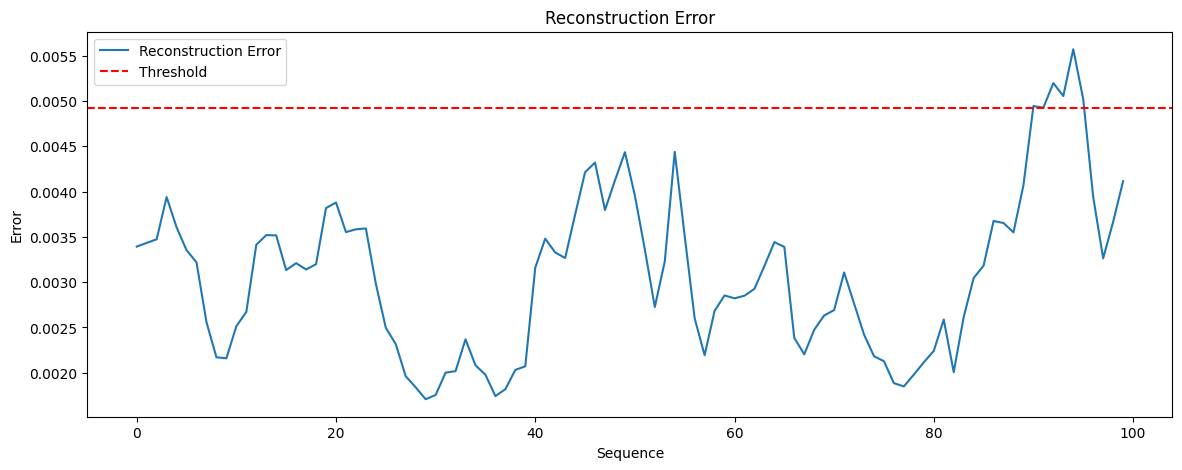

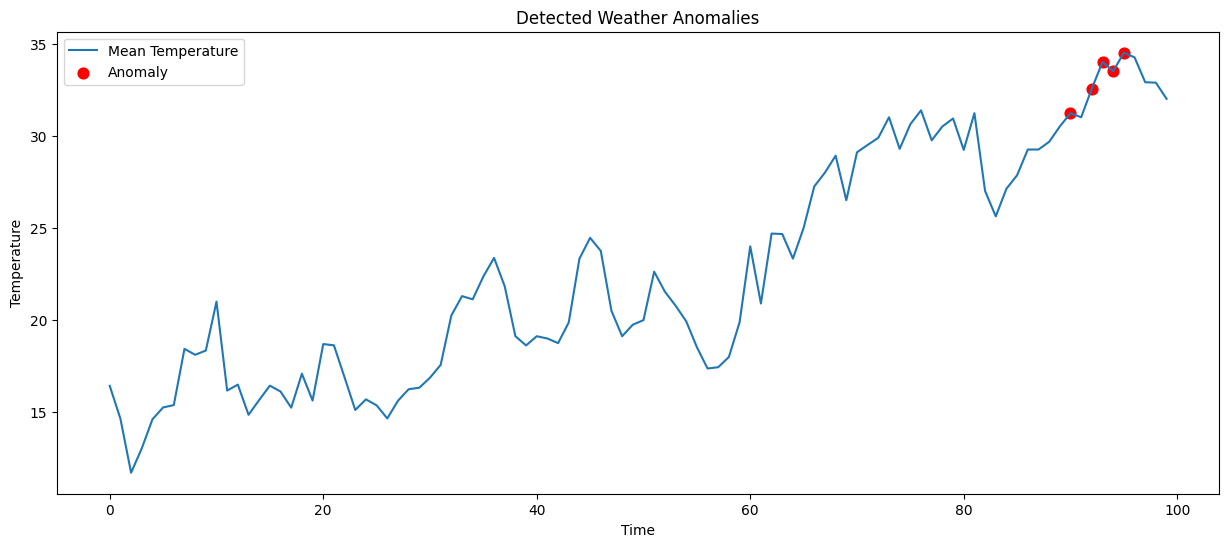

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from tensorflow.keras.models import load_model

# --------------------------------------------------
# Load Model & Scaler
# --------------------------------------------------
model = load_model("weather_anomaly_detector1.keras")
scaler = joblib.load("scaler.pkl")

# --------------------------------------------------
# Load Test Dataset
# --------------------------------------------------
df = pd.read_csv("/content/DailyDelhiClimateTest.csv")

features = [
    "meantemp",
    "humidity",
    "wind_speed",
    "meanpressure"
]

data = df[features]

# --------------------------------------------------
# Handle Missing Values
# --------------------------------------------------
data = data.apply(pd.to_numeric, errors="coerce")
data = data.ffill().bfill()

# --------------------------------------------------
# Normalize
# --------------------------------------------------
scaled = scaler.transform(data)

# --------------------------------------------------
# Create Sequences
# --------------------------------------------------
TIME_STEPS = 14

def create_sequences(dataset, time_steps):
    X = []
    for i in range(len(dataset) - time_steps):
        X.append(dataset[i:i+time_steps])
    return np.array(X)

X_test = create_sequences(scaled, TIME_STEPS)

print("Test Shape:", X_test.shape)

# --------------------------------------------------
# Predict
# --------------------------------------------------
predictions = model.predict(X_test)

# --------------------------------------------------
# Reconstruction Error
# --------------------------------------------------
mse = np.mean(np.square(X_test - predictions), axis=(1,2))

# --------------------------------------------------
# Threshold
# --------------------------------------------------
# Option 1: Use the threshold computed during training
# threshold = 0.0025   # Replace with your saved value

# Option 2: Estimate from test data (only for demonstration)
threshold = np.percentile(mse, 95)

print("Threshold:", threshold)

# --------------------------------------------------
# Detect Anomalies
# --------------------------------------------------
anomalies = mse > threshold

print("Total Anomalies:", anomalies.sum())

# --------------------------------------------------
# Create Results DataFrame
# --------------------------------------------------
results = pd.DataFrame({
    "date": df["date"][TIME_STEPS:].reset_index(drop=True),
    "reconstruction_error": mse,
    "anomaly": anomalies
})

print(results.head())

# --------------------------------------------------
# Print Anomaly Dates
# --------------------------------------------------
print("\nDetected Anomalies:\n")
print(results[results["anomaly"]])

# --------------------------------------------------
# Plot Reconstruction Error
# --------------------------------------------------
plt.figure(figsize=(14,5))

plt.plot(mse, label="Reconstruction Error")

plt.axhline(
    threshold,
    color="red",
    linestyle="--",
    label="Threshold"
)

plt.xlabel("Sequence")
plt.ylabel("Error")
plt.title("Reconstruction Error")
plt.legend()
plt.show()

# --------------------------------------------------
# Plot Temperature with Anomalies
# --------------------------------------------------
temperature = df["meantemp"][TIME_STEPS:].reset_index(drop=True)

plt.figure(figsize=(15,6))

plt.plot(temperature, label="Mean Temperature")

anomaly_index = np.where(anomalies)[0]

plt.scatter(
    anomaly_index,
    temperature.iloc[anomaly_index],
    color="red",
    s=60,
    label="Anomaly"
)

plt.xlabel("Time")
plt.ylabel("Temperature")
plt.title("Detected Weather Anomalies")
plt.legend()
plt.show()